In [87]:
import matplotlib.pyplot as plt
import numpy as np

In [88]:
# using TadaKit to load the data and get the dataframe for the processed step

from tadatakit.classes import Experiment
from pathlib import Path

rheology_json_file = './2cp_pg.json'
experiment = Experiment.from_json(rheology_json_file)

In [89]:
experiment.schema

Schema(url='https://software.tainstruments.com/schemas/TRIOSJSONExportSchema')

In [90]:
dataframes=experiment.get_dataframes_by_step('processed')
dataframes[0]


['Flow-Sweep : \nTemperature 20 °C Inherit Set Point: Off \nSoak Time 0.0 s Wait For Temperature: Off \nLogarithmic sweep\r\nShear rate 1000.0 1/s to 1.0e-3 1/s\r\nPoints per decade 10 \nSteady state sensing: On\nMax. equilibration time 1000.0 s\nSample period 3.0 s\n% tolerance 1.0 \nConsecutive within 2 \nScaled time average: On\nScale factor 1.0 \nAuto\r\nSave point display: Off\nLimit checking Enabled: Off\r\nEquilibrium Enabled: Off\n\n',
 'Oscillation-Amplitude : \nTemperature Inherit Set Point: On \nSoak Time 0.0 s Wait For Temperature: Off \nAngular frequency 1.0 rad/s\r\nLogarithmic sweep\r\nStrain % 10000.0 % to 0.1 %\r\nPoints per decade 10 \nContinuous oscillation [direct strain]\r\nAuto\r\nAcquisition Mode: Correlation\r\nTime 3.0 s\r\nTime 3.0 s\r\nSave waveform (point display): On\r\nNumber of points in waveform 64 \r\nSave image: Off\r\nUse additional harmonics: Off\r\nLimit checking Enabled: Off\r\nEquilibrium Enabled: Off\n\n',
 'Oscillation-Frequency : \nTemperature 

In [91]:
for item in dataframes[1][0].columns:
    print(item)

Displacement / rad
Axial force / N
Gap / µm
Shear rate / 1/s
Normal stress / Pa
Normal stress coefficient / Pa.s²
Viscosity / Pa.s
Torque (step) / µN.m
Strain constant / 1/rad
Displacement (step) / rad
Torque / µN.m
Step time / s
1/temperature / 1/K
Run time / s
Compliance / 1/MPa
Strain (step) / %
Modulus / Pa
Results Step Id
Termination reason
Temperature / °C
Stress (step) / Pa
Procedure Step Id
Date and time
Time / s
Velocity / rad/s
Strain / %
Stress / Pa
Storage modulus / Pa
Complex viscosity / Pa.s
Dynamic viscosity / Pa.s
Angular frequency / rad/s
Complex modulus / Pa
Loss compliance / 1/MPa
Storage compliance / 1/MPa
Raw phase / °
Oscillation strain / %
Oscillation torque (sample) / µN.m
Oscillation stress (cmd) / Pa
Oscillation strain (cmd) / %
Frequency / Hz
Stiffness / N.m/rad
G*/sin(delta) / kPa
G*.sin(delta) / kPa
Tan(delta)
Oscillation strain rate / 1/s
Oscillation torque / µN.m
Oscillation stress / Pa
Phase angle / °
Complex compliance / 1/MPa
Loss modulus / Pa
Out of p

Flow-Sweep : 
Temperature 20 °C Inherit Set Point: Off 
Soak Time 0.0 s Wait For Temperature: Off 
Logarithmic sweep
Shear rate 1000.0 1/s to 1.0e-3 1/s
Points per decade 10 
Steady state sensing: On
Max. equilibration time 1000.0 s
Sample period 3.0 s
% tolerance 1.0 
Consecutive within 2 
Scaled time average: On
Scale factor 1.0 
Auto
Save point display: Off
Limit checking Enabled: Off
Equilibrium Enabled: Off




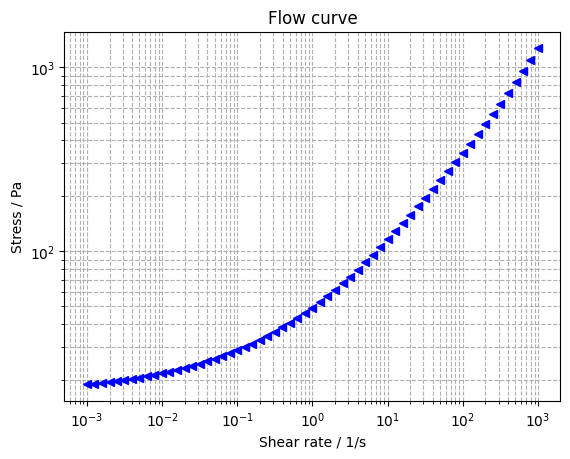

In [92]:
Flow_curve_down=dataframes[1][0]
print(dataframes[0][0])
fig_up, ax_up = plt.subplots()
ax_up.plot(Flow_curve_down['Shear rate / 1/s'], Flow_curve_down['Stress / Pa'], '<', color='blue')
ax_up.set_xlabel('Shear rate / 1/s')
ax_up.set_ylabel('Stress / Pa')
ax_up.set_title('Flow curve')
ax_up.set_xscale('log')
ax_up.set_yscale('log')
ax_up.grid(True, which="both", ls="--")

Flow-Sweep : 
Temperature Inherit Set Point: On 
Soak Time 0.0 s Wait For Temperature: Off 
Logarithmic sweep
Shear rate 1.0e-3 1/s to 1000.0 1/s
Points per decade 10 
Steady state sensing: On
Max. equilibration time 1000.0 s
Sample period 3.0 s
% tolerance 1.0 
Consecutive within 2 
Scaled time average: On
Scale factor 1.0 
Auto
Save point display: On
Limit checking Enabled: Off
Equilibrium Enabled: Off




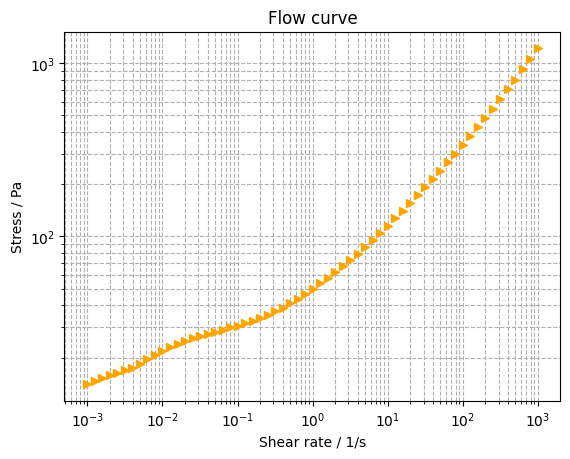

In [93]:
Flow_curve_up=dataframes[1][3]
print(dataframes[0][3])

fig_up, ax_up = plt.subplots()
ax_up.plot(Flow_curve_up['Shear rate / 1/s'], Flow_curve_up['Stress / Pa'], '>', color='orange')
ax_up.set_xlabel('Shear rate / 1/s')
ax_up.set_ylabel('Stress / Pa')
ax_up.set_title('Flow curve')
ax_up.set_xscale('log')
ax_up.set_yscale('log')
ax_up.grid(True, which="both", ls="--")

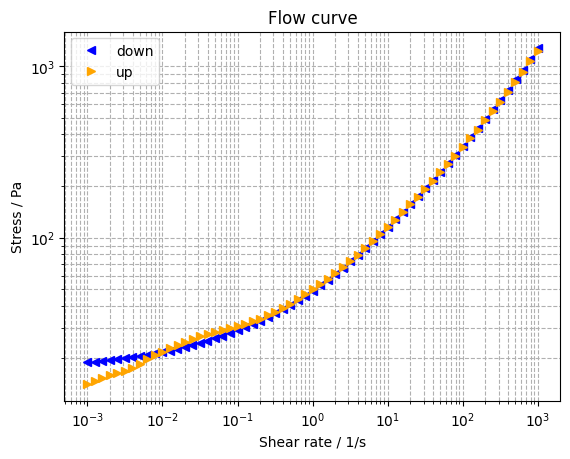

In [94]:
# plot both curves in the same plot
fig, ax = plt.subplots()
ax.plot(Flow_curve_down['Shear rate / 1/s'], Flow_curve_down['Stress / Pa'], '<', color='blue', label='down')
ax.plot(Flow_curve_up['Shear rate / 1/s'], Flow_curve_up['Stress / Pa'], '>', color='orange', label='up')
ax.set_xlabel('Shear rate / 1/s')
ax.set_ylabel('Stress / Pa')
ax.set_title('Flow curve')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which="both", ls="--")
ax.legend()


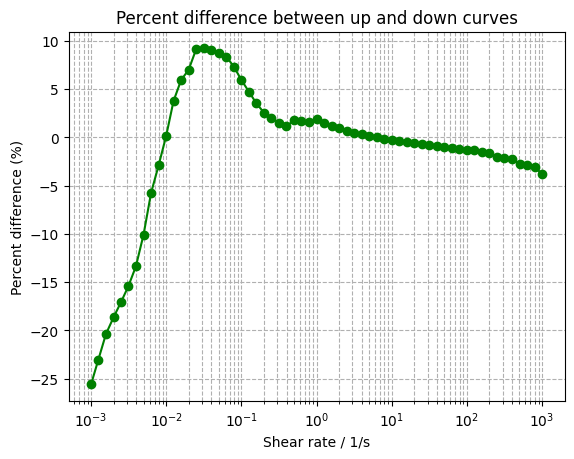

In [95]:
# plot the % difference betwween the two curves
fig, ax = plt.subplots()
shear_rate = Flow_curve_down['Shear rate / 1/s'].values
stress_down = Flow_curve_down['Stress / Pa'].values
stress_up = np.interp(shear_rate, Flow_curve_up['Shear rate / 1/s'].values, Flow_curve_up['Stress / Pa'].values)
percent_diff = (stress_up - stress_down) / stress_down * 100
ax.plot(shear_rate, percent_diff, 'o-', color='green')
ax.set_xlabel('Shear rate / 1/s')
ax.set_ylabel('Percent difference (%)')
ax.set_title('Percent difference between up and down curves')
ax.set_xscale('log')
ax.grid(True, which="both", ls="--")